In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

## Data

In [4]:
# Data Prepping

# copy r_table completely to keep backup
rdf = r_table.copy()

# Add 2 more columns,
# - target at previous trial
# - response at previous trial

rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)

# Replace NaN values in the first trial of each group with the current trial's value
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

rdf


,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,exp,...,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir,prev_target,prev_resp
0,1,0,0,0,159.0,145.788047,148.685925,2.897877,2.897877,145.788047,...,1.0,1.0,divided,high,expected,132,373,higher,145.788047,148.685925
1,1,0,0,1,123.0,136.060195,129.253756,6.806439,-6.806439,145.788047,...,1.0,1.0,focused,high,unexpected,204,280,lower,145.788047,148.685925
2,1,0,0,2,51.0,33.954344,124.965094,91.010750,91.010750,145.788047,...,0.0,0.0,focused,high,unexpected,168,250,higher,136.060195,129.253756
3,1,0,0,3,159.0,145.788047,145.702460,0.085587,-0.085587,145.788047,...,1.0,1.0,divided,high,expected,168,337,lower,33.954344,124.965094
4,1,0,0,4,15.0,18.896223,144.334808,125.438585,125.438585,145.788047,...,0.0,0.0,divided,low,unexpected,180,270,higher,145.788047,145.702460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34555,12,3,5,115,51.0,37.827708,161.360749,123.533041,123.533041,NaN,...,0.0,0.0,focused,high,NaN,168,292,higher,37.827708,84.768486
34556,12,3,5,116,15.0,3.855904,37.650337,33.794433,33.794433,NaN,...,0.0,0.0,divided,high,NaN,156,364,higher,37.827708,161.360749
34557,12,3,5,117,159.0,153.077094,85.831991,67.245104,-67.245104,NaN,...,0.0,0.0,focused,low,NaN,156,401,lower,3.855904,37.650337
34558,12,3,5,118,123.0,138.552340,152.674066,14.121726,14.121726,NaN,...,1.0,0.0,divided,low,NaN,156,384,higher,153.077094,85.831991


In [5]:
# Modeling setup:
# - emissions : resp
# - inputs : t_calib, prev_target, prev_resp

# Training a global model - use all data combined
emissions = jnp.array(np.deg2rad(rdf['resp'].values.reshape(-1, 120,1)))
inputs = jnp.array(np.deg2rad(rdf[['t_calib', 'prev_target', 'prev_resp']].values.reshape(-1, 120,3)))

emissions.shape, inputs.shape

((288, 120, 1), (288, 120, 3))

## Global initializer

In [6]:
num_states, input_dim, emission_dim = 2, 3, 1

In [7]:
global_params = {}

for nstate in tqdm(range(2, 10)):
    model = CircularRegressionHMM(nstate, input_dim, emission_dim)
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    subset_idx = np.random.choice(np.arange(0, len(emissions)), len(emissions), replace=False)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions[subset_idx], inputs = inputs[subset_idx], num_iters = 100, verbose = False)
    global_params[nstate] = fit_params

 50%|█████     | 4/8 [00:20<00:20,  5.02s/it]E0220 20:07:29.357103   40613 hlo_lexer.cc:443] Failed to parse int literal: 554909908499626281254
E0220 20:07:29.543474   40613 hlo_lexer.cc:443] Failed to parse int literal: 215766023842092697283172
100%|██████████| 8/8 [00:40<00:00,  5.04s/it]


In [8]:
with open('./caches/global_params.pkl', 'wb') as f:
    pickle.dump(global_params, f)

In [9]:
num_states, input_dim, emission_dim = 2, 3, 1
global_crossval = {}

for nstate in tqdm(range(2, 10)):
    model = CircularRegressionHMM(nstate, input_dim, emission_dim)
    # make index of emissions size and shufflei t
    shuffled_indices = np.random.permutation(emissions.shape[0])
    parameters, properties = model.initialize(key=jr.PRNGKey(nstate), method="kmeans", emissions = emissions[shuffled_indices])
    ll_mean, ll = cross_validate_regressor(model=model, emissions=emissions[shuffled_indices], key=jr.PRNGKey(0), num_iters=100, inputs=inputs[shuffled_indices])
    global_crossval[nstate] = ll

100%|██████████| 8/8 [03:22<00:00, 25.32s/it]


In [10]:
with open('./caches/global_crossval.pkl', 'wb') as f:
    pickle.dump(global_crossval, f)

## Crossvalidate subject models LOO

In [11]:
crossval_results = {}

for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 120, 1), inputs.reshape(12, 4 * 6, 120, 3))):
    crossval_results[idx] = {}
    shuffle_idx = np.random.permutation(len(s_em))
    
    for nstate in tqdm(range(2, 10), desc=f'sub-{idx+1}'):
        model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        gpar = global_params[nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                  method="prior",
                                                  initial_probs=gpar.initial.probs,
                                                  transition_matrix=gpar.transitions.transition_matrix,
                                                  emission_weights=gpar.emissions.weights,
                                                  emission_biases=gpar.emissions.biases,
                                                  emission_covariances=gpar.emissions.covs,)
        ll_mean, ll = cross_validate_regressor(model=model, emissions=s_em[shuffle_idx], key=jr.PRNGKey(0), num_iters=100, inputs=s_in[shuffle_idx], init = (parameters, properties))
        crossval_results[idx][nstate] = ll

sub-12: 100%|██████████| 8/8 [00:23<00:00,  3.00s/it]


In [12]:
with open('./caches/sub_crossval_results.pkl', 'wb') as f:
    pickle.dump(crossval_results, f)

In [13]:
# with open('./caches/sub_crossval_results.pkl', 'rb') as f:
#     crossval_results = pickle.load(f)

## Subject models

Therefore according to the cross val, it suggests x states so now we full train on those x states

In [7]:
with open('./caches/global_params.pkl', 'rb') as f:
    global_params = pickle.load(f)

# with open('./caches/sub_crossval_results.pkl', 'rb') as f:
#     crossval_results = pickle.load(f)

In [ ]:
subject_params = {}

for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 120, 1), inputs.reshape(12, 4 * 6, 120, 3))):
    subject_params[idx] = {}
    shuffle_idx = np.random.permutation(len(s_em))
    
    for nstate in tqdm(range(2, 10), desc=f'sub-{idx+1}'):
        model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        gpar = global_params[nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                  method="prior",
                                                  initial_probs=gpar.initial.probs,
                                                  transition_matrix=gpar.transitions.transition_matrix,
                                                  emission_weights=gpar.emissions.weights,
                                                  emission_biases=gpar.emissions.biases,
                                                  emission_covariances=gpar.emissions.covs,)
        fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 100, verbose = False)
        
        subject_params[idx][nstate] = fit_params

sub-1:   0%|          | 0/8 [00:02<?, ?it/s]


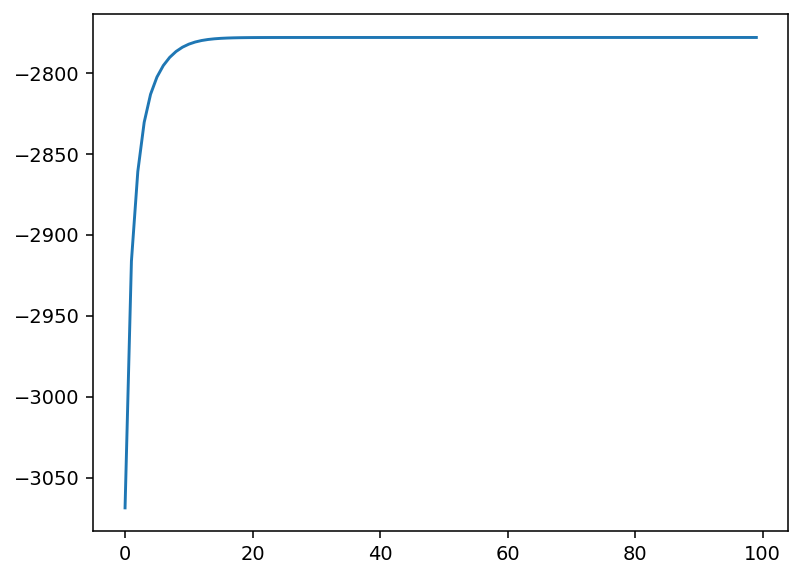

In [10]:
plt.plot(lps)

In [16]:
with open('./caches/subject_params.pkl', 'wb') as f:
    pickle.dump(subject_params, f)